# Lab 2 — Streaming Language Modeling Blocks

This lab shows a streaming input pipeline for **language modeling** that:
- Streams raw text from WikiText-2 (no local full download)
- Tokenizes with the GPT-2 tokenizer
- Packs tokens into **fixed-length blocks** with optional **overlap**
- Measures tokens/sec and visualizes overlap trade-offs
- Peeks at decoded blocks for sanity


In [1]:
import time, random
import torch
from torch.utils.data import IterableDataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

MODEL_NAME = "gpt2"
BLOCK_SIZE = 128
OVERLAPS = [0, 32, 64]  # Try different overlaps to see throughput effects
SAMPLE_BLOCKS_PER_SETTING = 400


c:\Users\shrut\Desktop\Swetha_MLOps\Labs\Data_Labs\LLM_Data_Pipeline\LLM_DATA_PIPELINE_NEW\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def rolling_token_blocks(token_iter, block_size: int, pad_token_id: int, overlap: int = 0, drop_last: bool = False):
    """
    Packs a running stream of token IDs into fixed-size blocks.
      - overlap > 0 reuses trailing tokens from the previous block
      - drop_last=False pads the tail to a full block when the stream ends
    """
    assert 0 <= overlap < block_size
    step = block_size - overlap
    buffer = []

    for tokens in token_iter:
        buffer.extend(tokens)
        # Emit as many full blocks as possible
        while len(buffer) >= block_size:
            chunk = buffer[:block_size]
            buffer = buffer[step:]
            yield torch.tensor(chunk, dtype=torch.long)

    if buffer and not drop_last:
        padded = buffer + [pad_token_id] * (block_size - len(buffer))
        yield torch.tensor(padded, dtype=torch.long)


In [3]:
# GPT-2 uses no pad by default; set pad to eos for collation-friendly behavior
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
tok.pad_token = tok.eos_token

# Stream raw text from WikiText-2
stream = load_dataset("wikitext", "wikitext-2-raw-v1", split="train", streaming=True)

# Build a generator of token ID lists (no special tokens added)
token_stream = (tok(ex["text"], add_special_tokens=False)["input_ids"] for ex in stream)


c:\Users\shrut\Desktop\Swetha_MLOps\Labs\Data_Labs\LLM_Data_Pipeline\LLM_DATA_PIPELINE_NEW\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shrut\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\shrut\Desktop\Swetha_MLOps\Labs\Data_Labs\LLM_Data_Pipeline

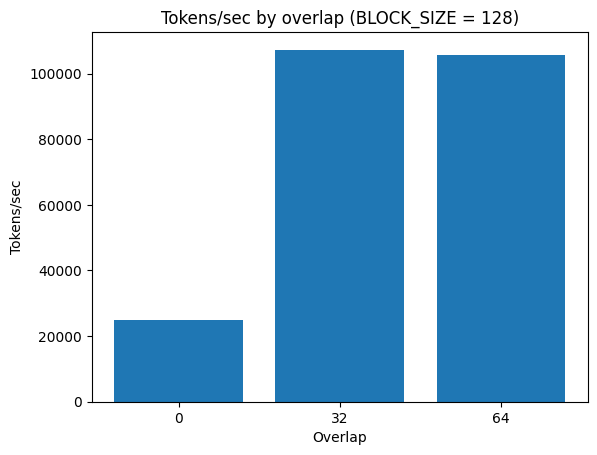

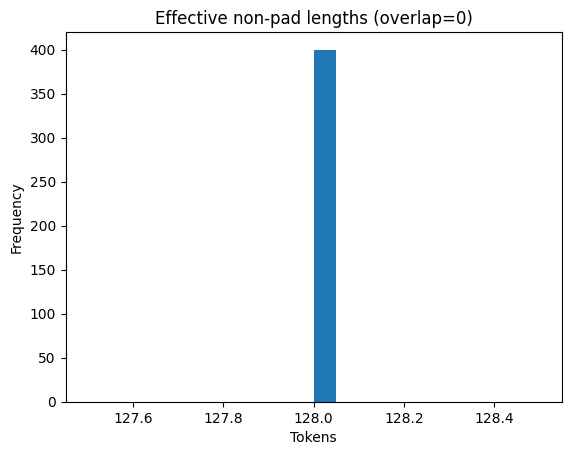

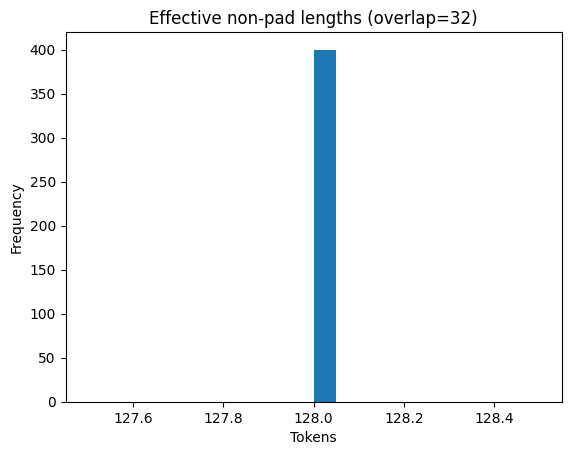

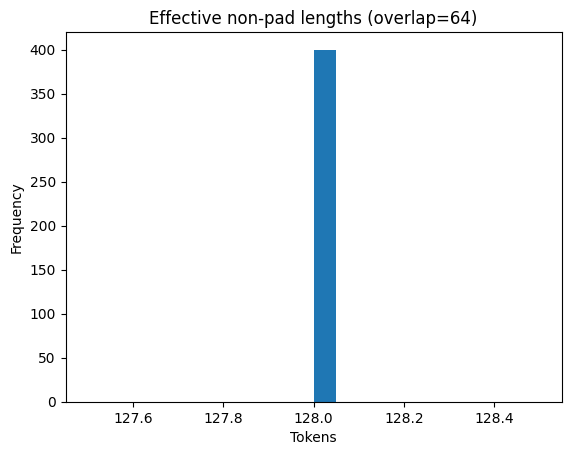

In [4]:
results = {}

for ov in OVERLAPS:
    # Make a fresh token stream per experiment so each loop starts from beginning
    stream = load_dataset("wikitext", "wikitext-2-raw-v1", split="train", streaming=True)
    token_stream = (tok(ex["text"], add_special_tokens=False)["input_ids"] for ex in stream)

    t0 = time.time()
    n_blocks, n_tokens = 0, 0
    lengths = []

    for i, block in enumerate(rolling_token_blocks(token_stream, BLOCK_SIZE, tok.pad_token_id, overlap=ov)):
        n_blocks += 1
        n_tokens += block.numel()
        # “Effective” non-pad length (for tail blocks)
        lengths.append(int((block != tok.pad_token_id).sum().item()))
        if n_blocks >= SAMPLE_BLOCKS_PER_SETTING:
            break

    dt = time.time() - t0
    results[ov] = {
        "blocks": n_blocks,
        "tokens": n_tokens,
        "tps": n_tokens / dt,
        "lengths": lengths,
    }

# Plot tokens/sec for each overlap
plt.figure()
plt.bar([str(k) for k in results.keys()], [v["tps"] for v in results.values()])
plt.title("Tokens/sec by overlap (BLOCK_SIZE = %d)" % BLOCK_SIZE)
plt.xlabel("Overlap")
plt.ylabel("Tokens/sec")
plt.show()

# Plot effective (non-pad) lengths per overlap
for ov in OVERLAPS:
    plt.figure()
    plt.hist(results[ov]["lengths"], bins=20)
    plt.title(f"Effective non-pad lengths (overlap={ov})")
    plt.xlabel("Tokens")
    plt.ylabel("Frequency")
    plt.show()


In [5]:
# Rebuild a stream and decode the first overlapped block for sanity
stream = load_dataset("wikitext", "wikitext-2-raw-v1", split="train", streaming=True)
token_stream = (tok(ex["text"], add_special_tokens=False)["input_ids"] for ex in stream)

for block in rolling_token_blocks(token_stream, BLOCK_SIZE, tok.pad_token_id, overlap=32):
    print(tok.decode(block, skip_special_tokens=True)[:300] + "…")
    break


 = Valkyria Chronicles III = 
 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStati…
